# Insula functional NMF (corrected waveform analysis)

Unsupervised discovery of **two insula waveform classes** from Hammers AIC/PIC electrodes.

**Principles (no anatomical label leakage):**
1. Fit NMF on the **stimulus epoch only** (temporal shape after rectify + L2 normalization).
2. Name components from waveform (`sensory_transient` vs `sustained_ramping`), not from AIC/PIC.
3. Use delay / go / response only as **held-out** characterizations; Hammers labels only for spatial validation.

Analysis logic lives in `src/nmf/` (tested).


In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy.stats import fisher_exact

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nmf.waveform_analysis import (
    PHASE_WINDOWS,
    TASKS,
    discover_paths,
    fit_nmf_grid,
    held_out_contrasts,
    load_hga_rows,
    orient_two_components,
    plot_model_selection,
    plot_spatial,
    plot_waveforms,
    prepare_shape_matrix,
    restrict_windows,
    stimulus_matrix,
    summarize_held_out,
    within_subject_permutation_p,
    write_component_table,
)

cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'
fontsize = 7

RESULTS_ROOT = ROOT / 'results'
OUTPUT_DIR = ROOT / 'tmp' / 'nmf_corrected'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_SUBJECTS = {'D0121'}
K_MAX = 6
N_INIT = 20
MAX_ITER = 5000
N_PERMUTATIONS = 10_000
RANDOM_STATE = 42

## 1. Stimulus discovery matrix

Electrodes: Hammers pure `AIC`/`PIC`, `mix=False`, `label!=0`, `Repeat` + `sound`, bilateral. Stimulus epoch must cover ≥95% of time samples.


In [2]:
all_paths = discover_paths(RESULTS_ROOT, TASKS)
print(f'HGA CSV files: {len(all_paths)}')

stimulus_rows = load_hga_rows(
    all_paths,
    phases={'stimulus'},
    exclude_subjects=EXCLUDE_SUBJECTS,
)
stimulus_rows = restrict_windows(stimulus_rows)
raw_matrix, metadata = stimulus_matrix(stimulus_rows)
X, keep = prepare_shape_matrix(raw_matrix.to_numpy())
raw_matrix = raw_matrix.iloc[np.flatnonzero(keep)]
metadata = metadata.iloc[np.flatnonzero(keep)]

print(
    f'Discovery matrix: {X.shape[0]} electrodes × {X.shape[1]} time points | '
    f'AIC={metadata["roi"].eq("AIC").sum()} PIC={metadata["roi"].eq("PIC").sum()} | '
    f'subjects={metadata["subject"].nunique()}'
)

HGA CSV files: 878
  read 100/230 files
  read 200/230 files
Discovery matrix: 110 electrodes × 191 time points | AIC=61 PIC=49 | subjects=47


## 2. Model selection (k = 1…6)

k=2 is supported when reconstruction error elbows and cosine silhouette on W peaks; stability (ARI across inits) is also reported.


  k=1: counts=[110] sil=nan stability=nan
  k=2: counts=[53, 57] sil=0.311 stability=1.000
  k=3: counts=[53, 43, 14] sil=0.305 stability=1.000
  k=4: counts=[51, 38, 13, 8] sil=0.244 stability=1.000
  k=5: counts=[24, 37, 12, 7, 30] sil=0.132 stability=1.000
  k=6: counts=[20, 13, 14, 9, 33, 21] sil=0.130 stability=1.000


,k,reconstruction_error,explained_energy,silhouette_cosine,stability_ari,min_cluster_n,cluster_counts,converged_runs,n_init
0,1,5.9492,0.6783,NaN,NaN,110,110,0,20
1,2,4.9003,0.7817,0.3111,1.0,53,53;57,20,20
2,3,4.4381,0.8209,0.3050,1.0,14,53;43;14,20,20
3,4,4.0825,0.8485,0.2445,1.0,8,51;38;13;8,20,20
4,5,3.7933,0.8692,0.1325,1.0,7,24;37;12;7;30,20,20
5,6,3.5163,0.8876,0.1298,1.0,9,20;13;14;9;33;21,20,20


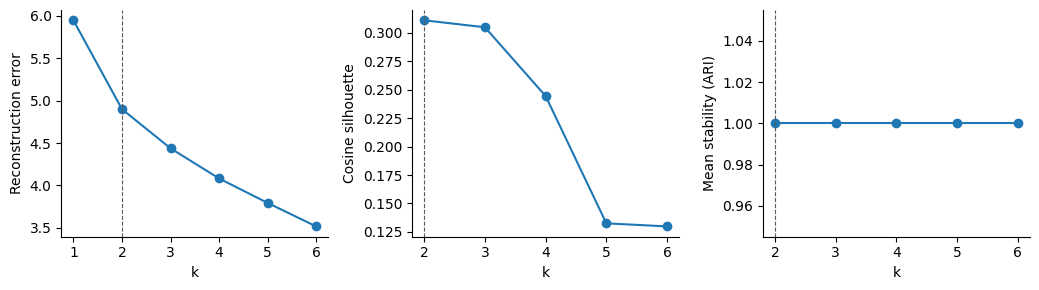

In [3]:
metrics, fits = fit_nmf_grid(
    X,
    k_max=K_MAX,
    n_init=N_INIT,
    random_state=RANDOM_STATE,
    max_iter=MAX_ITER,
)
display(metrics.round(4))

fig_k = plot_model_selection(metrics)
fig_k.savefig(OUTPUT_DIR / 'model_selection.png', dpi=240, bbox_inches='tight')
plt.show()

## 3. k = 2 functional clusters + Hammers validation

Hard assignment uses **normalized** NMF loadings. Anatomy (AIC/PIC) is evaluated only after clustering.


Functional cluster × Hammers atlas:


roi,AIC,PIC
functional_cluster,,
sustained_ramping,45,8
sensory_transient,16,41


,n_electrodes,n_subjects,anatomy_function_agreement,within_subject_permutation_p,fisher_odds_ratio,fisher_p_electrode_level
0,110,47,0.7818,0.0002,14.4141,0.0


Agreement=78.2%; permutation p=0.0002; OR=14.41 (Fisher p=1.223e-09)


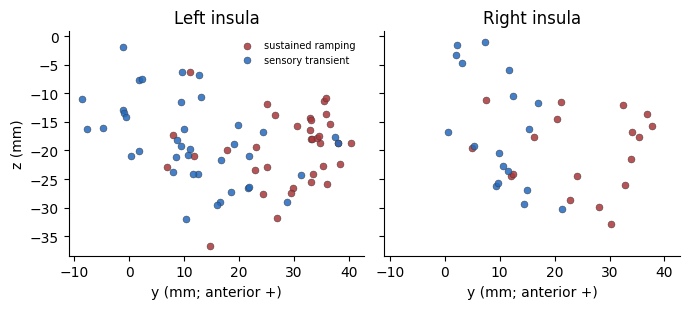

In [4]:
fit = fits[2]
W = np.asarray(fit['W'])
H = np.asarray(fit['H'])
component = np.asarray(fit['labels'], dtype=int)
times = raw_matrix.columns.to_numpy(float)
component_names = orient_two_components(H, times)
functional_cluster = np.array([component_names[c] for c in component])

assignments = metadata.reset_index().copy()
assignments['component'] = component
assignments['functional_cluster'] = functional_cluster
for comp_idx, name in component_names.items():
    assignments[f'loading_{name}'] = W[:, comp_idx]
assignments['dominance'] = W.max(axis=1) / np.maximum(W.sum(axis=1), 1e-12)

crosstab = pd.crosstab(assignments['functional_cluster'], assignments['roi']).reindex(
    index=['sustained_ramping', 'sensory_transient'],
    columns=['AIC', 'PIC'],
    fill_value=0,
)
odds_ratio, fisher_p = fisher_exact(crosstab.to_numpy())
agreement, permutation_p = within_subject_permutation_p(
    assignments['functional_cluster'].to_numpy(),
    assignments['roi'].to_numpy(),
    assignments['subject'].to_numpy(),
    n_permutations=N_PERMUTATIONS,
    random_state=RANDOM_STATE,
)

spatial_stats = pd.DataFrame([{
    'n_electrodes': len(assignments),
    'n_subjects': assignments['subject'].nunique(),
    'anatomy_function_agreement': agreement,
    'within_subject_permutation_p': permutation_p,
    'fisher_odds_ratio': odds_ratio,
    'fisher_p_electrode_level': fisher_p,
}])

print('Functional cluster × Hammers atlas:')
display(crosstab)
display(spatial_stats.round(4))
print(
    f'Agreement={agreement:.1%}; permutation p={permutation_p:.4g}; '
    f'OR={odds_ratio:.2f} (Fisher p={fisher_p:.4g})'
)

fig_sp = plot_spatial(assignments)
fig_sp.savefig(OUTPUT_DIR / 'spatial_yz.png', dpi=240, bbox_inches='tight')
plt.show()

## 4. Held-out waveforms (delay / go / response)

Subject-balanced means ± 95% CI across electrodes. Stimulus was used for clustering and is not re-tested here.


  read 100/878 files
  read 200/878 files
  read 300/878 files
  read 400/878 files
  read 500/878 files
  read 600/878 files
  read 700/878 files
  read 800/878 files


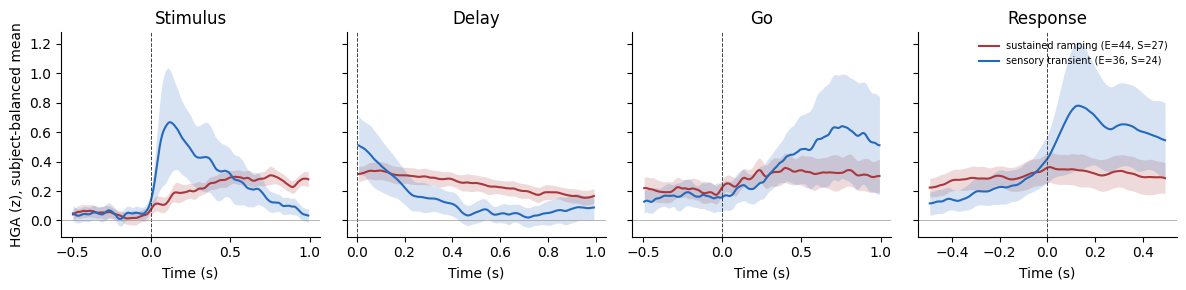

,functional_cluster,phase,n_channels,n_subjects
0,sensory_transient,delay,31,20
1,sensory_transient,go,21,19
2,sensory_transient,response,36,24
3,sensory_transient,stimulus,57,32
4,sustained_ramping,delay,44,25
5,sustained_ramping,go,38,24
6,sustained_ramping,response,44,27
7,sustained_ramping,stimulus,53,27


,contrast,test_type,n_subjects,mean_predicted_difference,wilcoxon_one_sided_p
0,delay_plateau,paired_between_cluster,6,0.174510,0.031250
1,response_peak,paired_between_cluster,9,0.283832,0.285156
2,sustained_delay_above_zero,one_sample_within_cluster,25,0.250434,0.000000
3,sensory_response_post_vs_pre,paired_within_cluster,24,0.457035,0.000325


In [5]:
held_out_rows = load_hga_rows(
    all_paths,
    phases=set(PHASE_WINDOWS),
    exclude_subjects=EXCLUDE_SUBJECTS,
    channels=set(assignments['channel']),
)
waveform_summary, coverage = summarize_held_out(held_out_rows, assignments)
contrasts = held_out_contrasts(held_out_rows, assignments)

fig_wf = plot_waveforms(waveform_summary, coverage)
fig_wf.savefig(OUTPUT_DIR / 'cluster_waveforms.png', dpi=240, bbox_inches='tight')
plt.show()

display(coverage)
display(
    contrasts[
        ['contrast', 'test_type', 'n_subjects', 'mean_predicted_difference', 'wilcoxon_one_sided_p']
    ].round(6)
)

## 5. Surface brain map (compute node)

Requires `ieeg` + off-screen Brain rendering. On login nodes this may fail; run on a compute node or submit `scripts/slurm/nmf_corrected_brain_render.sh`.


In [6]:
assignments.to_csv(OUTPUT_DIR / 'channel_assignments.csv', index=False)
metrics.to_csv(OUTPUT_DIR / 'model_selection_metrics.csv', index=False)
write_component_table(H, times, OUTPUT_DIR / 'stimulus_components.csv')
crosstab.to_csv(OUTPUT_DIR / 'functional_by_hammers.csv')
spatial_stats.to_csv(OUTPUT_DIR / 'spatial_validation.csv', index=False)
waveform_summary.to_csv(OUTPUT_DIR / 'held_out_waveform_summary.csv', index=False)
coverage.to_csv(OUTPUT_DIR / 'held_out_coverage.csv', index=False)
contrasts.to_csv(OUTPUT_DIR / 'held_out_contrasts.csv', index=False)

brain_png = OUTPUT_DIR / 'brain_functional_clusters.png'
try:
    from src.nmf.render_brain import render
    import argparse
    args = argparse.Namespace(
        assignments=OUTPUT_DIR / 'channel_assignments.csv',
        output=brain_png,
        recon_dir=Path('/cwork/ns458/ECoG_Recon/'),
        fs_subject='cvs_avg35_inMNI152',
    )
    render(args)
    display(Image(filename=str(brain_png)))
except Exception as exc:
    print(f'Brain render skipped: {exc}')
    print('Run: python -m src.nmf.run_render_brain --assignments', OUTPUT_DIR / 'channel_assignments.csv')

print(f'Wrote tables and figures to {OUTPUT_DIR}')

Using notebook 3d backend.
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


2026-07-19 18:01:57.905 (   2.600s) [    7FB24124E740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-19 18:01:57.967 (   2.662s) [    7FB24124E740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x78cef70): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl:

Brain render skipped: 'Namespace' object has no attribute 'size_min'
Run: python -m src.nmf.run_render_brain --assignments /hpc/group/coganlab/nanlinshi/insula/tmp/nmf_corrected/channel_assignments.csv
Wrote tables and figures to /hpc/group/coganlab/nanlinshi/insula/tmp/nmf_corrected


## Interpretation notes (for manuscript)

- **Sensory/transient** (blue): fast stimulus onset peak + decay; response epoch shows a within-cluster post > pre increase.
- **Sustained/ramping** (red): gradual rise after stimulus with a positive delay plateau.
- k=2 cosine silhouette is modest (~0.31); describe as two dominant waveform motifs, not a hard binary partition.
- Paired cluster comparisons at response require both classes within the same subject (small n); prefer within-cluster response tests for wording.


## 6. Per-phase NMF spatial maps (exploratory)

Same corrected pipeline (**rectify + L2 shape NMF, k=2**), but discovery is run **separately** on each phase (`stimulus`, `delay`, `go`, `response`). Component names still use early-minus-late of **H** (no anatomy). Compare whether the anterior sustained / posterior sensory gradient appears only for stimulus or also for other epochs.

In [7]:
from src.nmf.waveform_analysis import FUNCTION_COLORS, phase_matrix
from sklearn.metrics import adjusted_rand_score

PHASE_COMPARE_DIR = OUTPUT_DIR / 'phase_compare'
PHASE_COMPARE_DIR.mkdir(parents=True, exist_ok=True)

# Reuse all-phase rows if already loaded; otherwise load once.
try:
    _ = held_out_rows
except NameError:
    held_out_rows = load_hga_rows(
        all_paths,
        phases=set(PHASE_WINDOWS),
        exclude_subjects=EXCLUDE_SUBJECTS,
    )

all_phase_rows = restrict_windows(held_out_rows)

# Stimulus cluster labels as reference for ARI (if available from main analysis).
try:
    stimulus_ref = assignments.set_index('channel')['functional_cluster']
except NameError:
    stimulus_ref = None

phase_results = {}
summary_rows = []

for phase in PHASE_WINDOWS:
    raw_mat, meta = phase_matrix(all_phase_rows, phase)
    X_phase, keep = prepare_shape_matrix(raw_mat.to_numpy())
    raw_mat = raw_mat.iloc[np.flatnonzero(keep)]
    meta = meta.iloc[np.flatnonzero(keep)]

    metrics_p, fits_p = fit_nmf_grid(
        X_phase,
        k_max=2,
        n_init=N_INIT,
        random_state=RANDOM_STATE,
        max_iter=MAX_ITER,
    )
    fit_p = fits_p[2]
    W_p = np.asarray(fit_p['W'])
    H_p = np.asarray(fit_p['H'])
    labels_p = np.asarray(fit_p['labels'], dtype=int)
    times_p = raw_mat.columns.to_numpy(float)
    names_p = orient_two_components(H_p, times_p)
    cluster_p = np.array([names_p[c] for c in labels_p])

    assign_p = meta.reset_index().copy()
    assign_p['component'] = labels_p
    assign_p['functional_cluster'] = cluster_p
    for idx, name in names_p.items():
        assign_p[f'loading_{name}'] = W_p[:, idx]

    crosstab_p = pd.crosstab(assign_p['functional_cluster'], assign_p['roi']).reindex(
        index=['sustained_ramping', 'sensory_transient'],
        columns=['AIC', 'PIC'],
        fill_value=0,
    )
    agreement_p, perm_p = within_subject_permutation_p(
        assign_p['functional_cluster'].to_numpy(),
        assign_p['roi'].to_numpy(),
        assign_p['subject'].to_numpy(),
        n_permutations=N_PERMUTATIONS,
        random_state=RANDOM_STATE,
    )
    sil = float(metrics_p.loc[metrics_p['k'] == 2, 'silhouette_cosine'].iloc[0])

    ari = np.nan
    if stimulus_ref is not None:
        shared = assign_p.set_index('channel').index.intersection(stimulus_ref.index)
        if len(shared) >= 5:
            ari = adjusted_rand_score(
                stimulus_ref.loc[shared].to_numpy(),
                assign_p.set_index('channel').loc[shared, 'functional_cluster'].to_numpy(),
            )

    phase_results[phase] = {
        'assignments': assign_p,
        'crosstab': crosstab_p,
        'silhouette': sil,
        'agreement': agreement_p,
        'permutation_p': perm_p,
        'ari_vs_stimulus': ari,
        'n': len(assign_p),
    }
    summary_rows.append({
        'phase': phase,
        'n_electrodes': len(assign_p),
        'n_AIC': int((assign_p['roi'] == 'AIC').sum()),
        'n_PIC': int((assign_p['roi'] == 'PIC').sum()),
        'sustained_AIC': int(crosstab_p.loc['sustained_ramping', 'AIC']),
        'sustained_PIC': int(crosstab_p.loc['sustained_ramping', 'PIC']),
        'sensory_AIC': int(crosstab_p.loc['sensory_transient', 'AIC']),
        'sensory_PIC': int(crosstab_p.loc['sensory_transient', 'PIC']),
        'anatomy_agreement': agreement_p,
        'permutation_p': perm_p,
        'silhouette_cosine': sil,
        'ari_vs_stimulus_clusters': ari,
    })
    print(
        f'{phase:10s} n={len(assign_p):3d} sil={sil:.3f} '
        f'agree={agreement_p:.1%} ARI_vs_stim={ari:.3f}'
    )
    print(crosstab_p)
    print()

phase_summary = pd.DataFrame(summary_rows)
display(phase_summary.round(4))
phase_summary.to_csv(PHASE_COMPARE_DIR / 'phase_nmf_summary.csv', index=False)

  k=1: counts=[110] sil=nan stability=nan
  k=2: counts=[53, 57] sil=0.311 stability=1.000
stimulus   n=110 sil=0.311 agree=78.2% ARI_vs_stim=1.000
roi                 AIC  PIC
functional_cluster          
sustained_ramping    45    8
sensory_transient    16   41

  k=1: counts=[75] sil=nan stability=nan
  k=2: counts=[56, 19] sil=0.506 stability=1.000
delay      n= 75 sil=0.506 agree=69.3% ARI_vs_stim=0.204
roi                 AIC  PIC
functional_cluster          
sustained_ramping    39   17
sensory_transient     6   13

  k=1: counts=[59] sil=nan stability=nan
  k=2: counts=[29, 30] sil=0.360 stability=1.000
go         n= 59 sil=0.360 agree=57.6% ARI_vs_stim=0.033
roi                 AIC  PIC
functional_cluster          
sustained_ramping    22    8
sensory_transient    17   12

  k=1: counts=[80] sil=nan stability=nan
  k=2: counts=[54, 26] sil=0.492 stability=1.000
response   n= 80 sil=0.492 agree=45.0% ARI_vs_stim=0.051
roi                 AIC  PIC
functional_cluster          
su

,phase,n_electrodes,n_AIC,n_PIC,sustained_AIC,sustained_PIC,sensory_AIC,sensory_PIC,anatomy_agreement,permutation_p,silhouette_cosine,ari_vs_stimulus_clusters
0,stimulus,110,61,49,45,8,16,41,0.7818,0.0002,0.3111,1.0000
1,delay,75,45,30,39,17,6,13,0.6933,0.0179,0.5063,0.2041
2,go,59,39,20,22,8,17,12,0.5763,0.6659,0.3601,0.0332
3,response,80,50,30,30,24,20,6,0.4500,0.7294,0.4916,0.0509


In [8]:
# Four YZ spatial maps (Left / Right), one per discovery phase — same style as main analysis.
for phase, result in phase_results.items():
    assign_p = result['assignments']
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2), sharex=True, sharey=True)
    for axis, (hemi, title) in zip(axes, (('L', 'Left'), ('R', 'Right'))):
        side = assign_p.loc[assign_p['hemi'].eq(hemi)]
        for functional_cluster in ('sustained_ramping', 'sensory_transient'):
            points = side.loc[side['functional_cluster'].eq(functional_cluster)]
            axis.scatter(
                points['y'], points['z'], s=25,
                color=FUNCTION_COLORS[functional_cluster],
                edgecolor='0.2', linewidth=0.35, alpha=0.85,
                label=functional_cluster.replace('_', ' '),
            )
        axis.set_title(f'{title} insula')
        axis.set_xlabel('y (mm; anterior +)')
        axis.spines[['top', 'right']].set_visible(False)
    axes[0].set_ylabel('z (mm)')
    axes[0].legend(frameon=False, fontsize=7)
    fig.suptitle(
        f'NMF discovery on {phase}  '
        f'(n={result["n"]}, agree={result["agreement"]:.1%}, '
        f'sil={result["silhouette"]:.2f}, ARI vs stim={result["ari_vs_stimulus"]:.2f})',
        fontsize=9,
    )
    fig.tight_layout()
    out = PHASE_COMPARE_DIR / f'spatial_yz_{phase}.png'
    fig.savefig(out, dpi=240, bbox_inches='tight')
    plt.show()
    print(f'Saved {out}')

print(f'All phase-compare figures → {PHASE_COMPARE_DIR}')

Saved /hpc/group/coganlab/nanlinshi/insula/tmp/nmf_corrected/phase_compare/spatial_yz_stimulus.png
Saved /hpc/group/coganlab/nanlinshi/insula/tmp/nmf_corrected/phase_compare/spatial_yz_delay.png
Saved /hpc/group/coganlab/nanlinshi/insula/tmp/nmf_corrected/phase_compare/spatial_yz_go.png
Saved /hpc/group/coganlab/nanlinshi/insula/tmp/nmf_corrected/phase_compare/spatial_yz_response.png
All phase-compare figures → /hpc/group/coganlab/nanlinshi/insula/tmp/nmf_corrected/phase_compare
